# Oil & Gas Production Trends by State

This is a personal research project. I wanted to practice a skill that comes up constantly in real analyst jobs: starting from a vague question and figuring out, on my own, what data and approach would actually answer it.

I imagined a realistic (but made-up) situation: someone asking *"how have our wells been performing lately compared to last year?"* — a question that sounds simple but is actually missing a lot of detail. Before touching any data, I worked through what was actually being asked.

**What I ended up answering:** how crude oil and natural gas production have changed across U.S. states over the past year vs. the year before, and which states are trending up or down.

**Data:** U.S. Energy Information Administration (EIA) — real, official government data, current through June 2026.

## 1. Getting and Cleaning the Crude Oil Data

I pulled monthly crude oil production by state from the EIA. It only comes as an Excel file, not a CSV — that's just the format the government publishes it in.

In [1]:
import pandas as pd

oil_raw = pd.read_excel("../data/crude_oil_production_by_state.xls", sheet_name="Data 1", header=2)
oil_raw.shape

(1278, 43)

In [2]:
oil_raw.columns.tolist()

['Date',
 'U.S. Field Production of Crude Oil (Thousand Barrels)',
 'East Coast (PADD 1) Field Production of Crude Oil (Thousand Barrels)',
 'Florida Field Production of Crude Oil (Thousand Barrels)',
 'New York Field Production of Crude Oil (Thousand Barrels)',
 'Pennsylvania Field Production of Crude Oil (Thousand Barrels)',
 'Virginia Field Production of Crude Oil (Thousand Barrels)',
 'West Virginia Field Production of Crude Oil (Thousand Barrels)',
 'Midwest (PADD 2) Field Production of Crude Oil (Thousand Barrels)',
 'Illinois Field Production of Crude Oil (Thousand Barrels)',
 'Indiana Field Production of Crude Oil (Thousand Barrels)',
 'Kansas Field Production of Crude Oil (Thousand Barrels)',
 'Kentucky Field Production of Crude Oil (Thousand Barrels)',
 'Michigan Field Production of Crude Oil (Thousand Barrels)',
 'Missouri Field Production of Crude Oil (Thousand Barrels)',
 'Nebraska Field Production of Crude Oil (Thousand Barrels)',
 'North Dakota Field Production of Crude 

### A messy column list, with a hidden trap

The file mixes real states together with things that aren't states: a national total, 5 regional subtotals, and 2 "federal offshore" columns.

The sneaky one: `Alaska`, `Alaska South`, and `Alaska North Slope` all show up separately — but the last two are just the two pieces that add up to Alaska's own total. Keeping all three would count Alaska's oil twice.

Instead of trying to write a rule for "what to exclude" (which would miss that Alaska trap completely), I just wrote out the exact list of real states I wanted to keep — an allow-list. Anything not on it gets dropped automatically, so nothing sneaks through by accident.

In [3]:
states_to_keep = [
    "Florida", "New York", "Pennsylvania", "Virginia", "West Virginia",
    "Illinois", "Indiana", "Kansas", "Kentucky", "Michigan", "Missouri",
    "Nebraska", "North Dakota", "Ohio", "Oklahoma", "South Dakota", "Tennessee",
    "Alabama", "Arkansas", "Louisiana", "Mississippi", "New Mexico", "Texas",
    "Colorado", "Idaho", "Montana", "Utah", "Wyoming",
    "Alaska", "Arizona", "California", "Nevada"
]


These 32 states aren't a choice I made — it's simply every state the EIA tracks oil production for individually. The rest produce too little to be worth breaking out on their own.

In [4]:
oil_cols = ["Date"] + [f"{state} Field Production of Crude Oil (Thousand Barrels)" for state in states_to_keep]
oil_states = oil_raw[oil_cols]
oil_states.shape

(1278, 33)

In [5]:
oil_states.head()


,Date,Florida Field Production of Crude Oil (Thousand Barrels),New York Field Production of Crude Oil (Thousand Barrels),Pennsylvania Field Production of Crude Oil (Thousand Barrels),Virginia Field Production of Crude Oil (Thousand Barrels),West Virginia Field Production of Crude Oil (Thousand Barrels),Illinois Field Production of Crude Oil (Thousand Barrels),Indiana Field Production of Crude Oil (Thousand Barrels),Kansas Field Production of Crude Oil (Thousand Barrels),Kentucky Field Production of Crude Oil (Thousand Barrels),...,Texas Field Production of Crude Oil (Thousand Barrels),Colorado Field Production of Crude Oil (Thousand Barrels),Idaho Field Production of Crude Oil (Thousand Barrels),Montana Field Production of Crude Oil (Thousand Barrels),Utah Field Production of Crude Oil (Thousand Barrels),Wyoming Field Production of Crude Oil (Thousand Barrels),Alaska Field Production of Crude Oil (Thousand Barrels),Arizona Field Production of Crude Oil (Thousand Barrels),California Field Production of Crude Oil (Thousand Barrels),Nevada Field Production of Crude Oil (Thousand Barrels)
0,1920-01-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1920-02-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1920-03-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1920-04-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1920-05-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
oil_states.tail()


,Date,Florida Field Production of Crude Oil (Thousand Barrels),New York Field Production of Crude Oil (Thousand Barrels),Pennsylvania Field Production of Crude Oil (Thousand Barrels),Virginia Field Production of Crude Oil (Thousand Barrels),West Virginia Field Production of Crude Oil (Thousand Barrels),Illinois Field Production of Crude Oil (Thousand Barrels),Indiana Field Production of Crude Oil (Thousand Barrels),Kansas Field Production of Crude Oil (Thousand Barrels),Kentucky Field Production of Crude Oil (Thousand Barrels),...,Texas Field Production of Crude Oil (Thousand Barrels),Colorado Field Production of Crude Oil (Thousand Barrels),Idaho Field Production of Crude Oil (Thousand Barrels),Montana Field Production of Crude Oil (Thousand Barrels),Utah Field Production of Crude Oil (Thousand Barrels),Wyoming Field Production of Crude Oil (Thousand Barrels),Alaska Field Production of Crude Oil (Thousand Barrels),Arizona Field Production of Crude Oil (Thousand Barrels),California Field Production of Crude Oil (Thousand Barrels),Nevada Field Production of Crude Oil (Thousand Barrels)
1273,2026-02-15,58.0,12.0,565.0,0.0,1211.0,484.0,94.0,1940.0,155.0,...,162789.0,12690.0,2.0,2211.0,5075.0,7952.0,11638.0,0.0,6859.0,1.0
1274,2026-03-15,68.0,13.0,603.0,0.0,1347.0,571.0,113.0,2122.0,137.0,...,179490.0,14321.0,1.0,2458.0,5779.0,9011.0,12961.0,1.0,7653.0,14.0
1275,2026-04-15,76.0,13.0,478.0,1.0,1211.0,536.0,114.0,2047.0,35.0,...,175525.0,13807.0,0.0,2446.0,5674.0,8627.0,12658.0,1.0,7311.0,14.0
1276,2026-05-15,82.0,13.0,433.0,0.0,1173.0,527.0,112.0,2112.0,264.0,...,179886.0,14094.0,0.0,2405.0,5913.0,8865.0,12881.0,0.0,7613.0,14.0
1277,2026-06-15,78.0,13.0,396.0,0.0,1118.0,526.0,108.0,2045.0,183.0,...,171848.0,13339.0,0.0,2065.0,6079.0,8935.0,12378.0,0.0,7374.0,14.0


The data goes back to 1920, so the earliest rows are empty for these state columns (states weren't tracked individually that far back). That's fine, since I only care about the last couple of years — confirmed the recent rows have real numbers.

## 2. Reshaping the Data

The file has one column per state. To combine this with other tables later, I needed one row per state per month instead. This kind of reshaping is called melting.

In [7]:
oil_long = oil_states.melt(id_vars="Date", var_name="State_Raw", value_name="Oil_Production")
oil_long.shape


(40896, 3)

In [8]:
oil_long["State"] = oil_long["State_Raw"].str.replace(" Field Production of Crude Oil (Thousand Barrels)", "", regex=False)
oil_long[["State_Raw", "State"]].head()


,State_Raw,State
0,Florida Field Production of Crude Oil (Thousan...,Florida
1,Florida Field Production of Crude Oil (Thousan...,Florida
2,Florida Field Production of Crude Oil (Thousan...,Florida
3,Florida Field Production of Crude Oil (Thousan...,Florida
4,Florida Field Production of Crude Oil (Thousan...,Florida


In [9]:
oil_long = oil_long[["Date", "State", "Oil_Production"]]
oil_long.head()


,Date,State,Oil_Production
0,1920-01-15,Florida,NaN
1,1920-02-15,Florida,NaN
2,1920-03-15,Florida,NaN
3,1920-04-15,Florida,NaN
4,1920-05-15,Florida,NaN


After melting, I cleaned up the state names and filtered down to just the last 24 months, since that's the window the question actually needs.

One thing worth noting: I didn't just grab the last 24 rows of the table. After melting, all of one state's history sits together as a block, then the next state's, and so on — so "the last 24 rows" would only be one state's data (Nevada, alphabetically last), not the recent months from every state. Filtering by actual date avoids that trap.

In [10]:
oil_recent = oil_long[oil_long["Date"] >= "2024-07-01"]
oil_recent.shape


(768, 3)

In [11]:
oil_recent["Oil_Production"].isnull().sum()


np.int64(0)

In [12]:
oil_recent.head()

,Date,State,Oil_Production
1254,2024-07-15,Florida,65.0
1255,2024-08-15,Florida,80.0
1256,2024-09-15,Florida,71.0
1257,2024-10-15,Florida,67.0
1258,2024-11-15,Florida,65.0


Crude oil is clean: 768 rows, the last 24 months, all 32 states, no missing values.

## 3. Doing the Same for Natural Gas

I repeated the same cleaning steps for natural gas — this file turned out simpler, with no regional subtotals and no Alaska-style trap, just 16 states tracked individually.

In [13]:
gas_raw = pd.read_excel("../data/natural_gas_withdrawals_by_state.xls", sheet_name="Data 1", header=2)
gas_raw.shape


(642, 19)

In [14]:
gas_states_to_keep = [
    "Alaska", "Arkansas", "California", "Colorado", "Kansas", "Louisiana",
    "Montana", "New Mexico", "North Dakota", "Ohio", "Oklahoma",
    "Pennsylvania", "Texas", "Utah", "West Virginia", "Wyoming"
]


In [15]:
gas_cols = ["Date"] + [f"{state} Natural Gas Gross Withdrawals (MMcf)" for state in gas_states_to_keep]
gas_states = gas_raw[gas_cols]
gas_states.shape


(642, 17)

In [16]:
gas_long = gas_states.melt(id_vars="Date", var_name="State_Raw", value_name="Gas_Withdrawals")
gas_long.shape


(10272, 3)

In [17]:
gas_long["State"] = gas_long["State_Raw"].str.replace(" Natural Gas Gross Withdrawals (MMcf)", "", regex=False)
gas_long[["State_Raw", "State"]].head()


,State_Raw,State
0,Alaska Natural Gas Gross Withdrawals (MMcf),Alaska
1,Alaska Natural Gas Gross Withdrawals (MMcf),Alaska
2,Alaska Natural Gas Gross Withdrawals (MMcf),Alaska
3,Alaska Natural Gas Gross Withdrawals (MMcf),Alaska
4,Alaska Natural Gas Gross Withdrawals (MMcf),Alaska


In [18]:
gas_long = gas_long[["Date", "State", "Gas_Withdrawals"]]
gas_recent = gas_long[gas_long["Date"] >= "2024-07-01"]
gas_recent.shape


(384, 3)

In [19]:
gas_recent["Gas_Withdrawals"].isnull().sum()


np.int64(0)

In [20]:
gas_recent.head()

,Date,State,Gas_Withdrawals
618,2024-07-15,Alaska,275384.0
619,2024-08-15,Alaska,262261.0
620,2024-09-15,Alaska,266664.0
621,2024-10-15,Alaska,299939.0
622,2024-11-15,Alaska,308355.0


Natural gas is clean too: 384 rows, 16 states, no missing values.

## 4. Building a States → Region Table

I built a third small table mapping each state to its official government region (the EIA calls these PADDs — a regional grouping set up decades ago for tracking fuel supply). Grouping 32 states into just 5 regions makes the big picture much easier to read. I built this by hand, using the same regional groupings already visible in the oil file's own column structure — [verifiable on EIA's own PADD map](https://www.eia.gov/petroleum/marketing/monthly/paddmap.php).

In [21]:
region_ref = pd.read_csv("../data/states_region_reference.csv")
region_ref.head()


,State,Region,PADD_Number
0,Florida,East Coast,1
1,New York,East Coast,1
2,Pennsylvania,East Coast,1
3,Virginia,East Coast,1
4,West Virginia,East Coast,1


## 5. Loading Everything into a SQL Database

At this point I had 3 separate tables — oil, gas, and the region lookup. That's completely normal; real company data is almost always split across multiple tables like this. To actually combine them, I loaded all three into a small SQL database.

In [22]:
import sqlite3

conn = sqlite3.connect("../data/oil_gas.db")
oil_recent.to_sql("oil_production", conn, if_exists="replace", index=False)
gas_recent.to_sql("gas_production", conn, if_exists="replace", index=False)
region_ref.to_sql("states_region", conn, if_exists="replace", index=False)


32

## 6. Joining the Tables

A join combines rows from separate tables by matching a shared value — here, the state name. First, a simple one: attach each state's region to its oil data.

In [23]:
query = """
SELECT oil_production.Date, oil_production.State, oil_production.Oil_Production, states_region.Region
FROM oil_production
JOIN states_region ON oil_production.State = states_region.State
LIMIT 10;
"""
pd.read_sql_query(query, conn)


,Date,State,Oil_Production,Region
0,2024-07-15 00:00:00,Florida,65.0,East Coast
1,2024-08-15 00:00:00,Florida,80.0,East Coast
2,2024-09-15 00:00:00,Florida,71.0,East Coast
3,2024-10-15 00:00:00,Florida,67.0,East Coast
4,2024-11-15 00:00:00,Florida,65.0,East Coast
5,2024-12-15 00:00:00,Florida,63.0,East Coast
6,2025-01-15 00:00:00,Florida,61.0,East Coast
7,2025-02-15 00:00:00,Florida,55.0,East Coast
8,2025-03-15 00:00:00,Florida,64.0,East Coast
9,2025-04-15 00:00:00,Florida,65.0,East Coast


### Adding gas data: why LEFT JOIN, not a regular JOIN

Oil covers 32 states; gas only covers 16. A regular join only keeps rows that match in *both* tables — which would silently delete all 16 states that don't produce gas, without any warning. A LEFT JOIN instead keeps every oil row no matter what, and just leaves gas blank where there's no match.

Checked both sides below: Florida (no gas) correctly shows blank instead of disappearing, and Texas (has both) shows real numbers for each.

In [24]:
query = """
SELECT 
    oil_production.Date, 
    oil_production.State, 
    oil_production.Oil_Production, 
    gas_production.Gas_Withdrawals,
    states_region.Region
FROM oil_production
LEFT JOIN gas_production 
    ON oil_production.State = gas_production.State 
    AND oil_production.Date = gas_production.Date
JOIN states_region 
    ON oil_production.State = states_region.State
LIMIT 15;
"""
pd.read_sql_query(query, conn)


,Date,State,Oil_Production,Gas_Withdrawals,Region
0,2024-07-15 00:00:00,Florida,65.0,None,East Coast
1,2024-08-15 00:00:00,Florida,80.0,None,East Coast
2,2024-09-15 00:00:00,Florida,71.0,None,East Coast
3,2024-10-15 00:00:00,Florida,67.0,None,East Coast
4,2024-11-15 00:00:00,Florida,65.0,None,East Coast
5,2024-12-15 00:00:00,Florida,63.0,None,East Coast
6,2025-01-15 00:00:00,Florida,61.0,None,East Coast
7,2025-02-15 00:00:00,Florida,55.0,None,East Coast
8,2025-03-15 00:00:00,Florida,64.0,None,East Coast
9,2025-04-15 00:00:00,Florida,65.0,None,East Coast


In [25]:
query = """
SELECT 
    oil_production.Date, 
    oil_production.State, 
    oil_production.Oil_Production, 
    gas_production.Gas_Withdrawals,
    states_region.Region
FROM oil_production
LEFT JOIN gas_production 
    ON oil_production.State = gas_production.State 
    AND oil_production.Date = gas_production.Date
JOIN states_region 
    ON oil_production.State = states_region.State
WHERE oil_production.State = 'Texas'
LIMIT 5;
"""
pd.read_sql_query(query, conn)


,Date,State,Oil_Production,Gas_Withdrawals,Region
0,2024-07-15 00:00:00,Texas,176049.0,1102835.0,Gulf Coast
1,2024-08-15 00:00:00,Texas,178676.0,1115472.0,Gulf Coast
2,2024-09-15 00:00:00,Texas,173534.0,1073182.0,Gulf Coast
3,2024-10-15 00:00:00,Texas,181130.0,1126668.0,Gulf Coast
4,2024-11-15 00:00:00,Texas,173768.0,1081663.0,Gulf Coast


In [26]:
query = """
SELECT 
    oil_production.Date, 
    oil_production.State, 
    oil_production.Oil_Production, 
    gas_production.Gas_Withdrawals,
    states_region.Region
FROM oil_production
LEFT JOIN gas_production 
    ON oil_production.State = gas_production.State 
    AND oil_production.Date = gas_production.Date
JOIN states_region 
    ON oil_production.State = states_region.State
"""
combined = pd.read_sql_query(query, conn)
combined.shape


(768, 5)

## 7. Comparing Year Over Year

With all 3 tables joined, I labeled each row as "Prior Year" (Jul 2024–Jun 2025) or "Recent Year" (Jul 2025–Jun 2026), so I could compare the two periods directly.

In [27]:
query = """
SELECT 
    oil_production.Date, 
    oil_production.State, 
    oil_production.Oil_Production, 
    gas_production.Gas_Withdrawals,
    states_region.Region,
    CASE 
        WHEN oil_production.Date >= '2025-07-01' THEN 'Recent Year'
        ELSE 'Prior Year'
    END AS Period
FROM oil_production
LEFT JOIN gas_production 
    ON oil_production.State = gas_production.State 
    AND oil_production.Date = gas_production.Date
JOIN states_region 
    ON oil_production.State = states_region.State
"""
combined = pd.read_sql_query(query, conn)
combined.shape


(768, 6)

In [28]:
combined["Period"].value_counts()


Period
Prior Year     384
Recent Year    384
Name: count, dtype: int64

In [29]:
state_totals = combined.groupby(["State", "Period"])["Oil_Production"].sum().reset_index()
state_totals.head()


,State,Period,Oil_Production
0,Alabama,Prior Year,3104.0
1,Alabama,Recent Year,3080.0
2,Alaska,Prior Year,155827.0
3,Alaska,Recent Year,151105.0
4,Arizona,Prior Year,1.0


Next, I totaled up production for each state in each period, then laid the two periods side by side so I could compare them directly.

In [30]:
pivot = state_totals.pivot(index="State", columns="Period", values="Oil_Production")
pivot.head()


Period,Prior Year,Recent Year
State,,
Alabama,3104.0,3080.0
Alaska,155827.0,151105.0
Arizona,1.0,2.0
Arkansas,3993.0,3738.0
California,108915.0,96344.0


I compared the two periods using **percent change**, not the raw difference. Reason: Alaska's raw drop (~4,722 barrels) looks bigger than Arizona's (1 barrel) — but Arizona's production actually doubled, while Alaska only fell about 3%. Percent change puts every state on a fair, comparable scale, instead of letting huge states drown out real swings in small ones.

In [31]:
pivot["Pct_Change"] = (pivot["Recent Year"] - pivot["Prior Year"]) / pivot["Prior Year"] * 100
pivot.sort_values("Pct_Change", ascending=False)


Period,Prior Year,Recent Year,Pct_Change
State,,,
Arizona,1.0,2.0,100.000000
Pennsylvania,4317.0,5080.0,17.674311
West Virginia,13208.0,15507.0,17.406118
Ohio,44576.0,51502.0,15.537509
New Mexico,773102.0,834982.0,8.004118
Florida,796.0,823.0,3.391960
Montana,27993.0,28896.0,3.225806
Texas,2092798.0,2111820.0,0.908927
Kentucky,1759.0,1769.0,0.568505


### A trap hiding in the numbers

Look at **Arizona: +100%** — sounds dramatic, but it went from **1 barrel to 2 barrels**. That's noise, not a trend. The same problem shows up for **Virginia (-37.5%, from 8 to 5)**, **Idaho (-28%, from 25 to 18)**, and **Missouri (-11.3%, from 53 to 47)**. A percentage built on a tiny number swings wildly and doesn't mean anything real.

So before drawing any conclusions, I filtered down to states with a large enough production base for the percentage to actually be trustworthy.

In [32]:
major_producers = pivot[pivot["Prior Year"] >= 1000].sort_values("Pct_Change", ascending=False)
major_producers


Period,Prior Year,Recent Year,Pct_Change
State,,,
Pennsylvania,4317.0,5080.0,17.674311
West Virginia,13208.0,15507.0,17.406118
Ohio,44576.0,51502.0,15.537509
New Mexico,773102.0,834982.0,8.004118
Montana,27993.0,28896.0,3.225806
Texas,2092798.0,2111820.0,0.908927
Kentucky,1759.0,1769.0,0.568505
Oklahoma,145662.0,145517.0,-0.099546
Utah,68066.0,67850.0,-0.317339


This is the real, defensible answer: 23 major-producing states, ranked. **New Mexico (+8.0%)** is the strongest genuine grower. **Texas (+0.9%)** is essentially flat, but because it's so massive, that's still the largest raw increase of any state. **Pennsylvania, West Virginia, and Ohio (+15–18%)** show the strongest relative growth. **Mississippi, Michigan, Louisiana, and California (-12% to -17%)** show real, meaningful declines.

## 8. Charts

Three charts tell this story: which states are up or down, what the trend actually looks like over time for the biggest movers, and which region dominates overall.

### Chart 1: Which States Are Trending Up vs. Down

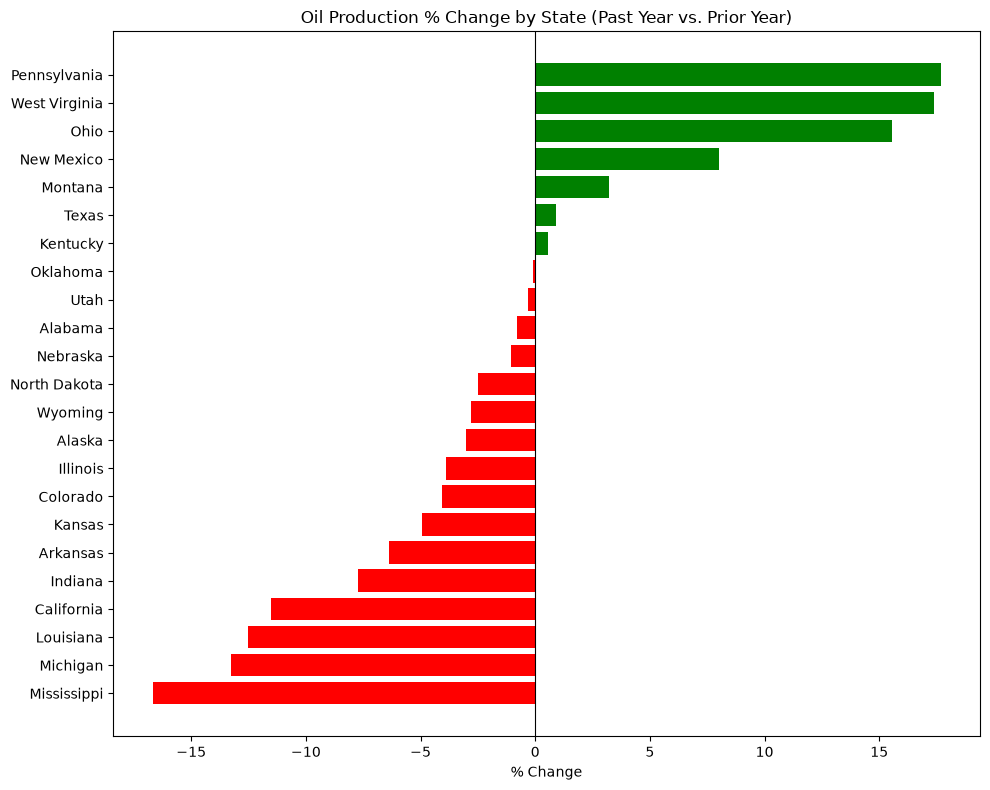

In [33]:
import matplotlib.pyplot as plt

chart_data = major_producers.sort_values("Pct_Change")
colors = ["green" if x >= 0 else "red" for x in chart_data["Pct_Change"]]

plt.figure(figsize=(10, 8))
plt.barh(chart_data.index, chart_data["Pct_Change"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Oil Production % Change by State (Past Year vs. Prior Year)")
plt.xlabel("% Change")
plt.tight_layout()
plt.savefig("../images/oil_pct_change_by_state.png", bbox_inches="tight")
plt.show()


**Reading this chart:** among the 23 major-producing states, **7 grew and 16 declined** over the past year. **Pennsylvania (+17.7%), West Virginia (+17.4%), and Ohio (+15.5%)** lead the gainers — a real, consistent growth signal across three neighboring Appalachian states. **New Mexico (+8.0%)** is the strongest grower among the truly large-scale producers, and **Texas (+0.9%)** rounds out the green bars, essentially flat but still technically positive. On the decline side, **Mississippi (-16.7%) fell the furthest**, followed by **Michigan (-13.3%), Louisiana (-12.5%), and California (-11.5%)** — all real, double-digit declines, not noise. The middle of the chart (Oklahoma through Arkansas, roughly -0.1% to -6.4%) represents more modest, though still genuine, softening across several major legacy-producing states like North Dakota, Wyoming, Colorado, and Alaska.

### Chart 2: Monthly Trend for the Top Movers

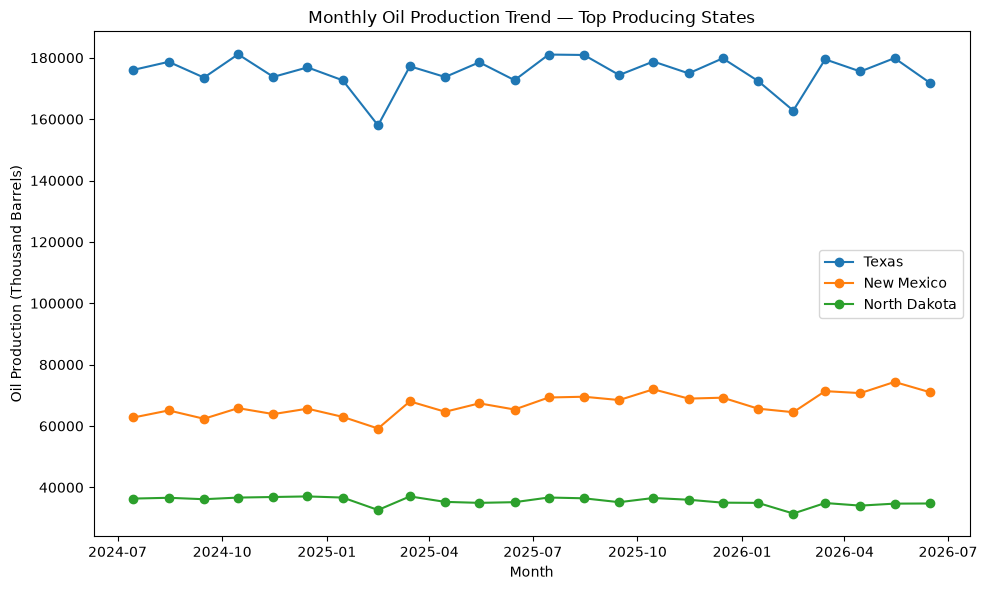

In [34]:
top_states = ["Texas", "New Mexico", "North Dakota"]
trend_data = oil_recent[oil_recent["State"].isin(top_states)]

plt.figure(figsize=(10, 6))
for state in top_states:
    state_data = trend_data[trend_data["State"] == state]
    plt.plot(state_data["Date"], state_data["Oil_Production"], marker="o", label=state)

plt.title("Monthly Oil Production Trend — Top Producing States")
plt.xlabel("Month")
plt.ylabel("Oil Production (Thousand Barrels)")
plt.legend()
plt.tight_layout()
plt.savefig("../images/top_states_oil_trend.png", bbox_inches="tight")
plt.show()


**Reading this chart:** **New Mexico (orange) shows a genuine, steady upward climb** — from 62,770 thousand barrels in July 2024 to 71,020 by June 2026, with its low point (59,182, February 2025) still well below its high point (74,359, May 2026), confirming this is real sustained growth, not a lucky two-point comparison. **Texas (blue) is volatile but essentially flat** — swinging between a low of 157,961 (February 2025) and a high of 181,130 (October 2024), with no clear upward or downward direction across the full 24 months. **North Dakota (green) sits essentially flat with a slight downward drift**, ranging narrowly between 31,471 (February 2026) and 37,051 (March 2025).

Notice Texas and North Dakota both dip around February 2025 (and again lightly around February 2026) — this looked like it might be a real event, but as the Deeper Analysis section further below shows, it isn't one.

### Chart 3: Production by Region

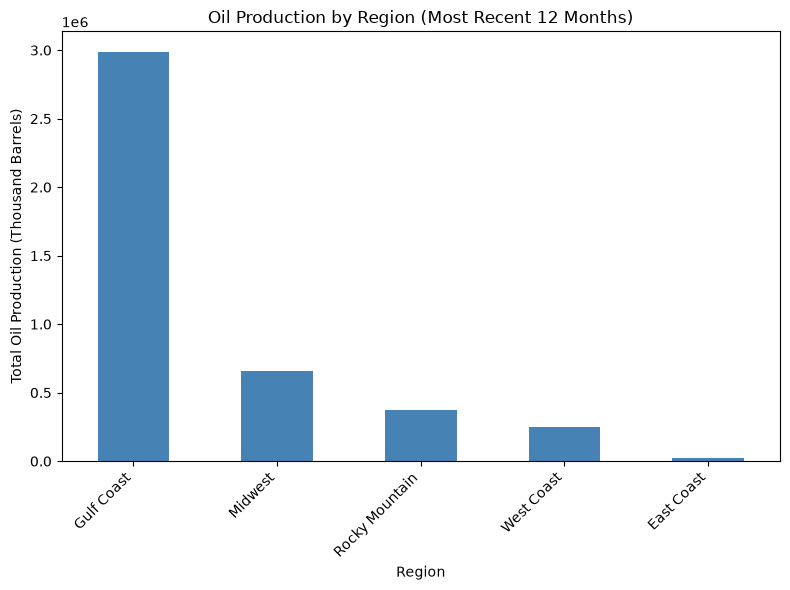

In [35]:
region_totals = combined[combined["Period"] == "Recent Year"].groupby("Region")["Oil_Production"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 6))
region_totals.plot(kind="bar", color="steelblue")
plt.title("Oil Production by Region (Most Recent 12 Months)")
plt.xlabel("Region")
plt.ylabel("Total Oil Production (Thousand Barrels)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../images/oil_production_by_region.png", bbox_inches="tight")
plt.show()


**Reading this chart:** the Gulf Coast region (Texas, Louisiana, New Mexico, and others) produced **2,988,039 thousand barrels** in the most recent 12 months — nearly **70% of all oil production** across the 5 regions combined, and **4.5x more** than the next-largest region, the Midwest (658,363 thousand barrels). Rocky Mountain (369,672) and West Coast (247,588) trail further behind, and the East Coast barely registers at just 21,570 — under 1% of the national total. This confirms what's true in the real world: **U.S. oil production is overwhelmingly concentrated in the Gulf Coast**, driven mainly by Texas's dominant scale, with every other region a distant secondary player.

## 9. Deeper Analysis: A February Dip That Wasn't Real

My first instinct looking at the dip in Chart 2 was to wonder if it reflected a real event — 28 of 32 states did show a decline from January to February 2025. But checking further caught something important: **February only has 28 days**, while most other months have 30 or 31. Once production is converted to a *daily rate* instead of a raw monthly total, the dip completely disappears — February 2025's daily rate (11,483 barrels/day) and February 2026's (11,714 barrels/day) are both entirely normal, right in line with every other month in the dataset (roughly 11,200–11,900/day across the board).

**What this means:** the apparent February dip was a calendar artifact, not a real production event. This is a good reminder to double-check *why* a pattern exists before trusting it — treating this as a real "weather-related" event without checking would have been a real mistake.

*(The day-count normalization code isn't in this notebook yet — this finding was verified separately and is a planned addition for a future session.)*

## 10. Conclusion

**New Mexico is the strongest genuine growth story among major oil-producing states (+8.0%)**, while **Texas remains essentially flat but still dominant in scale**, and a real growth signal is emerging across **Pennsylvania, West Virginia, and Ohio**. Four states — **Mississippi, Michigan, Louisiana, and California** — show meaningful declines worth investigating further. The Gulf Coast region alone accounts for nearly 70% of all U.S. oil production in this dataset. Full findings and recommendations are documented in [`README.md`](../README.md).